# ADE Corpus v2 Exploratory Data Analysis
This notebook walks through the exploratory data analysis that underpins the healthcare adverse event detection portfolio project. The emphasis is on interpreting the dataset characteristics (balance, leakage, text length) so downstream modeling choices are motivated by evidence instead of code experimentation.


## 1. Environment and Dataset Access
Install the local project in editable mode so its shared utilities are on the path, then download the `SetFit/ade_corpus_v2_classification` dataset from Hugging Face Datasets. This section simply ensures the environment is reproducible before we inspect any records.


In [1]:
%cd ..
%pip install -e .

/Users/fdiazja/Documents/machine_learning_projects/healthcare-nlp
Obtaining file:///Users/fdiazja/Documents/machine_learning_projects/healthcare-nlp
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for healthcare-nlp (pyproject.toml) ... done
  Created wheel for healthcare-nlp: filename=healthcare_nlp-0.1.0-0.editable-py3-none-any.whl size=1580 sha256=e8b93d0bf20063f706aef25e5a36af4dfe8a4af50ed403b82319999fcd0f03cd
  Stored in directory: /private/var/folders/2t/n2hgf_m559l2pdjm2jzyb3zr0000gn/T/pip-ephem-wheel-cache-l_13p90x/wheels/74/25/fc/bd0d9ce7f0a41dbed78c10d0a983d95fa76743970013542c2c
Successfully built healthcare-nlp
  Attempting uninstall: healthcare-nlp
    Found existing installation: healthcare-nlp 0.1.0
    Uninstalling healthcare-nlp-0.1.0:
      Successfully uninstalled healthcare-nlp-0.1.0
Note: 

In [2]:
import re
import pandas as pd
from datasets import load_dataset
from datasets.dataset_dict import DatasetDict
import seaborn as sns
import matplotlib.pyplot as plt 


ds: DatasetDict = load_dataset("SetFit/ade_corpus_v2_classification")

train_pd = ds["train"].to_pandas()
if isinstance(train_pd, pd.DataFrame):
    df_train = train_pd

else:
    df_train = pd.concat(list(train_pd), ignore_index=True)

test_pd = ds["test"].to_pandas()
if isinstance(test_pd, pd.DataFrame):
    df_test = test_pd

else:
    df_test = pd.concat(list(test_pd), ignore_index=True)

Repo card metadata block was not found. Setting CardData to empty.


## 2. First Look at Raw Records
Peek at a few rows from each split to verify that the `text`, `label`, and `label_text` columns are shaped as expected and that the binary labels map to the Related vs. Not-Related classes we plan to model.


In [3]:
df_train.head()

,text,label,label_text
0,"On cessation of the injections, the retrocorne...",0,Not-Related
1,Median patient age was 52 years.,0,Not-Related
2,A whole brain irradiation was performed for 37...,0,Not-Related
3,Complex biochemical syndrome of hypocalcemia a...,0,Not-Related
4,The fastidious organism grew only on buffered ...,0,Not-Related


In [4]:
df_test.head()

,text,label,label_text
0,The use of somatostatin analog in gastroentero...,0,Not-Related
1,The patient was given methimazole instead of p...,1,Related
2,Ethambutol is an antimicrobial agent used freq...,0,Not-Related
3,Dofetilide has been shown to be effective and ...,0,Not-Related
4,IgG1 and IgG4 were the predominant IgG subclas...,0,Not-Related


## 3. Data Quality Helper Functions
The next block defines lightweight helpers used throughout the notebook: text normalization (for duplicate checks), dataset reports (counts, duplicates, label balance), leakage reports (train/test overlap), formatted printing, and text-length utilities. Keeping these in one place makes the EDA more readable and keeps the focus on conclusions downstream.


In [5]:
# Text normalization
_ws = re.compile(r"\s+")

def normalize_text(s: str) -> str:
    """Lowercase text and collapse repeated whitespace."""
    s = str(s).strip().lower()
    return _ws.sub(" ", s)

In [6]:
def data_report(df: pd.DataFrame) -> dict:
    """Return counts, duplication stats, and label balance."""
    if "label" not in df.columns:
        raise ValueError("No 'label' column was found")
    if "label_text" not in df.columns:
        raise ValueError("No 'label_text' column was found")
    if "text" not in df.columns:
        raise ValueError("No 'text' column was found")

    num_rows = len(df)

    # Row-level duplicates
    num_row_dupes = num_rows - df.drop_duplicates().shape[0]

    # Text-level duplicates
    num_text_dupes = num_rows - df.drop_duplicates(subset=["text"]).shape[0]

    # Normalized text duplicates
    norm_text = df["text"].map(normalize_text)
    num_norm_text_dupes = (
        num_rows - pd.DataFrame({"_t": norm_text}).drop_duplicates().shape[0]
    )

    # Label balance
    bal = df["label"].value_counts(dropna=False).sort_index()

    # Imbalance ratio
    if len(bal) >= 2:
        imbalance_ratio = bal.max() / max(1, bal.min())
    else:
        imbalance_ratio = float("nan")

    # Nulls
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0].to_dict()

    report = {
        "dtypes": df.dtypes,
        "num_rows": num_rows,
        "duplicate_rows": num_row_dupes,
        "duplicate_texts": num_text_dupes,
        "duplicate_texts_normalized": num_norm_text_dupes,
        "labels": bal.index.to_numpy(),
        "examples_per_label": bal.to_dict(),
        "imbalance_ratio": imbalance_ratio,
        "text_labels": df["label_text"].unique(),
        "null_values": nulls,
    }

    return report

In [7]:
# Duplictae leakage
def leakage_report(
    df_train: pd.DataFrame, 
    df_test: pd.DataFrame,
    col: str = "text"
) -> dict:
    """Report normalized text overlap between the train and test splits."""
    if col not in (list(df_test.columns) and list(df_train.columns)):
        raise ValueError("Column for leakage analysis not in DataFrames!")
    
    train_text = df_train[col].astype(str).map(normalize_text)
    test_text = df_test[col].astype(str).map(normalize_text)
    train_set = set(train_text)
    test_set = set(test_text)
    overlap = train_set.intersection(test_set)
    return {
        "train_unique_texts": len(train_set),
        "test_unique_texts": len(test_set),
        "overlap_unique_texts": len(overlap),
        "overlap_pct_of_test_unique": (
            len(overlap) / max(1, len(test_set))
        ) * 100.0,
        "overlap_pct_of_train_unique": (
            len(overlap) / max(1, len(train_set))
        ) * 100.0,
    }    


In [8]:
# Display reports
def display_report(report: dict, title: str = "Report") -> None:
    """Pretty-print a metrics dictionary with a title."""
    print(f"======== {title} ========\n")

    for key, value in report.items():
        if isinstance(value, float):
            print(f"- {key}: {value:.3f}\n")
        else:
            print(f"- {key}: {value}\n")

In [9]:
# Text lenght distribution (count in words)
def get_text_len_data(
    df:pd.DataFrame, 
    col: str = "text",
) -> pd.DataFrame | pd.Series:
    """Compute per-record word counts for the chosen text column."""
    text_lens = df.copy()
    text_lens["text lengths"] = df[col].str.split().map(len)
    return text_lens["text lengths"]

def text_length_report(df: pd.DataFrame, col: str = "text") -> dict:
    """Summarize basic stats for the text-length distribution."""
    if col not in df.columns:
        raise ValueError(f"Column {col!r} not found in DataFrame!")
    
    text_lengths = get_text_len_data(df, col)
    return {
        "mean_length": text_lengths.mean(),
        "min_length": text_lengths.min(),
        "max_length": text_lengths.max(),
        "std_length": text_lengths.std(),
    }


## 4. Prepare Text-Length Features
Capture the per-record word counts for the training split so we can explore how long the clinical notes tend to be. This quick preview helps verify that there are no pathological record lengths before plotting distributions or summarizing statistics.


In [10]:
training_text_dist = get_text_len_data(df_train)

In [11]:
training_text_dist

0        16
1         6
2        31
3        15
4        21
         ..
17632    17
17633    22
17634    21
17635    29
17636    15
Name: text lengths, Length: 17637, dtype: int64

## 5. Dataset Diagnostics
With the helpers in place, compute summary reports for each split and measure potential leakage between train and test. The same section also produces descriptive statistics for the text-length distribution so we can compare central tendencies across splits.


In [12]:
data_rep_train = data_report(df_train)
data_rep_test = data_report(df_test)
leakage_rep = leakage_report(df_train, df_test)
len_rep_train = text_length_report(df_train)
len_rep_test = text_length_report(df_test)
display_report(data_rep_train, "Data report for training set")
display_report(data_rep_test, "Data report for test set")
display_report(leakage_rep, "Leakage report")
display_report(len_rep_train, "Text distribution for training set")
display_report(len_rep_test, "Text distribution for test set")

======== Data report for training set ========

- dtypes: text            str
label         int64
label_text      str
dtype: object

- num_rows: 17637

- duplicate_rows: 1718

- duplicate_texts: 1718

- duplicate_texts_normalized: 1719

- labels: [0 1]

- examples_per_label: {0: 12492, 1: 5145}

- imbalance_ratio: 2.428

- text_labels: <ArrowStringArray>
['Not-Related', 'Related']
Length: 2, dtype: str

- null_values: {}

======== Data report for test set ========

- dtypes: text            str
label         int64
label_text      str
dtype: object

- num_rows: 5879

- duplicate_rows: 253

- duplicate_texts: 253

- duplicate_texts_normalized: 253

- labels: [0 1]

- examples_per_label: {0: 4203, 1: 1676}

- imbalance_ratio: 2.508

- text_labels: <ArrowStringArray>
['Not-Related', 'Related']
Length: 2, dtype: str

- null_values: {}

======== Leakage report ========

- train_unique_texts: 15918

- test_unique_texts: 5626

- overlap_unique_texts: 649

- overlap_pct_of_test_unique: 11.536



### What stands out
- **Volume & balance:** Train contains 17,637 records (12,492 Not-Related vs. 5,145 Related) and test holds 5,879 records (4,203 vs. 1,676), yielding a consistent ~2.5× imbalance that the modeling pipeline must address with weighting or sampling.
- **Duplicates:** Roughly 1.7k duplicated rows/texts remain in train and 253 in test, so a deduplication pass could recover up to ~10% more unique training signals.
- **Leakage risk:** After normalizing whitespace/casing, 649 unique texts overlap between the splits (~11.5% of unique test notes). This is non-trivial leakage that should be removed or at least flagged before claiming generalization metrics.
- **Missing data:** No null values were found in any of the key columns, which means we can focus on label noise rather than imputation.
- **Text length stats:** Average record length hovers around 18 words with relatively tight spread (std ≈ 9 words) and a maximum of 135 words, so even long sequences remain manageable for lightweight transformer models.


## 6. Text-Length Distribution
Visualize the word-count histograms to understand whether the Related and Not-Related examples share similar length profiles and to spot outliers that might require truncation rules or special handling during tokenization.


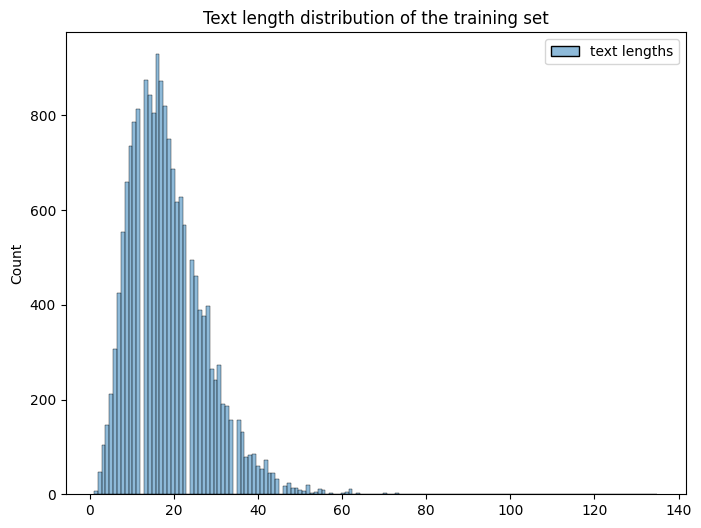

In [13]:
training_text_dist = pd.DataFrame(get_text_len_data(df_train))
plt.figure(figsize=(8, 6))
sns.histplot(data=training_text_dist) 
plt.title("Text length distribution of the training set")
plt.show()

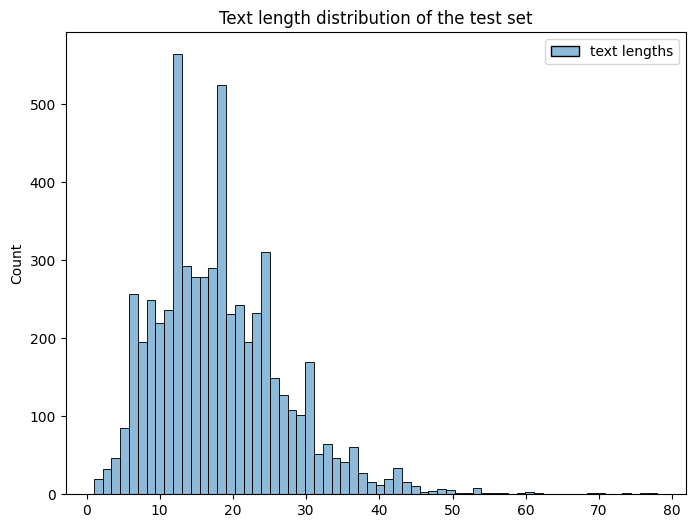

In [14]:
test_text_dist = pd.DataFrame(get_text_len_data(df_test))
plt.figure(figsize=(8, 6))
sns.histplot(data=test_text_dist) 
plt.title("Text length distribution of the test set")
plt.show()

## 7. Key Takeaways for the Portfolio Project
- Class imbalance is mild-to-moderate (~2.5×), so evaluation should report class-wise metrics and training should consider loss weighting.
- About 10–12% of records are duplicates or leak between splits; cleaning these up will yield more trustworthy validation scores.
- Texts are short (median well under 20 words), making it feasible to experiment with simple baselines (e.g., linear models over TF-IDF) alongside transformer encoders without worrying about severe truncation.
- Because the dataset looks clean otherwise (no nulls, consistent schema), the focus can shift toward curating robust evaluation slices (e.g., minority class) and experimenting with domain-specific embeddings.


In [15]:
overlap = df_train.merge(df_test)

In [16]:
df_train[~df_train["text"].isin(set(df_test["text"]))]

,text,label,label_text
0,"On cessation of the injections, the retrocorne...",0,Not-Related
1,Median patient age was 52 years.,0,Not-Related
2,A whole brain irradiation was performed for 37...,0,Not-Related
3,Complex biochemical syndrome of hypocalcemia a...,0,Not-Related
4,The fastidious organism grew only on buffered ...,0,Not-Related
...,...,...,...
17632,We believe this to be the second reported case...,0,Not-Related
17633,PURPOSE: Tandem scanning confocal microscopy w...,0,Not-Related
17634,We report 3 cases of ureteral obstruction foll...,0,Not-Related
17635,We speculate that platelet activation induced ...,1,Related
